# Imports && Initializations


In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
if not os.path.exists('plots'):
    os.makedirs('plots')
    print("Directory 'plots' created.")

## Create DF

In [3]:
df = pd.read_csv('../data/cleaned_movies_full.csv')

# See the first "row"
print(len(df))
print(df.head())
print("First entry:")

4669820
     User_ID   Movie_ID  Rating        Date
0  ur4592644  tt0120884      10  2005-01-16
1  ur3174947  tt0118688       3  2005-01-16
2  ur3780035  tt0387887       8  2005-01-16
3  ur4592628  tt0346491       1  2005-01-16
4  ur3174947  tt0094721       8  2005-01-16
First entry:


# Feature Engineering

## Pre - clustering

### Dimensionality Analysis

In [4]:
n_users = df['User_ID'].nunique()
n_movies = df['Movie_ID'].nunique()
n_ratings = len(df)

possible_ratings = n_users * n_movies
sparsity = 1 - (n_ratings / possible_ratings)

print(f"Users: {n_users} | Movies: {n_movies}")
print(f"Sparsity: {sparsity * 100:.2f}%")

Users: 1499238 | Movies: 351109
Sparsity: 100.00%


### Label enconding

In [5]:
user_enc = LabelEncoder()
movie_enc = LabelEncoder()

df['user_idx'] = user_enc.fit_transform(df['User_ID'])
df['movie_idx'] = movie_enc.fit_transform(df['Movie_ID'])

### Creating the "User Vectors" for Clustering

In [6]:
# Create a Compressed Sparse Row matrix
# row = user index, col = movie index, data = rating
user_movie_matrix = csr_matrix((df['Rating'], (df['user_idx'], df['movie_idx'])))

## Normalization

### ??? 1) Prohibit data from clustering people who give only 1 or 10 ???

In [7]:
# 1. Calculate the average rating for each user
User_Mean = df.groupby('User_ID')['Rating'].mean()

# 2. Subtract the mean to center the data around zero
# A positive 'Rating_Norm' means they liked it more than their average
df['Rating_Norm'] = df['Rating'] - df['User_ID'].map(User_Mean)

print("✅ Normalization complete.")
df[['User_ID', 'Rating', 'Rating_Norm']].head()

✅ Normalization complete.


,User_ID,Rating,Rating_Norm
0,ur4592644,10,0.000000
1,ur3174947,3,-4.355556
2,ur3780035,8,0.125000
3,ur4592628,1,0.000000
4,ur3174947,8,0.644444


### 2) Mean centering normalize ratings because some users are "easy graders" (average 9/10) and some are "harsh critics" (average 4/10). We want to know if a user liked a movie **more than their own average**

In [8]:
# 1. Calculate the average rating for each user
User_Mean = df.groupby('User_ID')['Rating'].mean()

# 2. Map those means back to the main dataframe
df['User_Mean'] = df['User_ID'].map(User_Mean)

# 3. Create the Normalized Rating (Relative Preference)
df['Rating_Norm'] = df['Rating'] - df['User_Mean']

print("✅ Normalization complete.")
print(df[['User_ID', 'Rating', 'User_Mean', 'Rating_Norm']].head())

✅ Normalization complete.
     User_ID  Rating  User_Mean  Rating_Norm
0  ur4592644      10  10.000000     0.000000
1  ur3174947       3   7.355556    -4.355556
2  ur3780035       8   7.875000     0.125000
3  ur4592628       1   1.000000     0.000000
4  ur3174947       8   7.355556     0.644444


#### "Easy vs. Harsh" grader

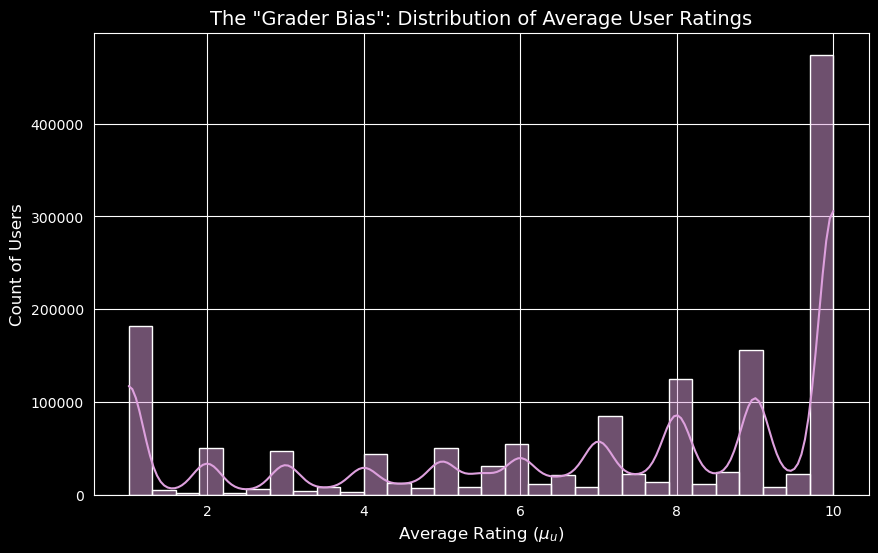

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(User_Mean, bins=30, color='plum', kde=True)

plt.title('The "Grader Bias": Distribution of Average User Ratings', fontsize=14)
plt.xlabel('Average Rating ($\mu_u$)', fontsize=12)
plt.ylabel('Count of Users', fontsize=12)

plt.savefig('plots/user_bias_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

#### Density of predictions to the user's baseline (for a sample up to 5000)

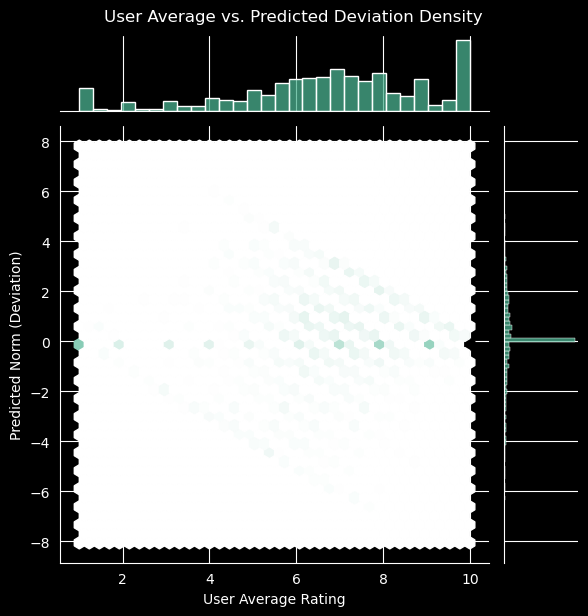

In [10]:
# Using a sample of 5000 points so the plot stays fast and readable
g = sns.jointplot(
    data=df.sample(min(5000, len(df))),
    x='User_Mean',         # Fixed name from user_means to User_Mean
    y='Rating_Norm',
    kind="hex",
    color="#4CB391"
)

g.fig.suptitle('User Average vs. Predicted Deviation Density', y=1.02)
g.set_axis_labels('User Average Rating', 'Predicted Norm (Deviation)')

plt.savefig('plots/prediction_joint_hex.png', dpi=300, bbox_inches='tight')
plt.show()

#### Feature Relationships (**Correlation**)

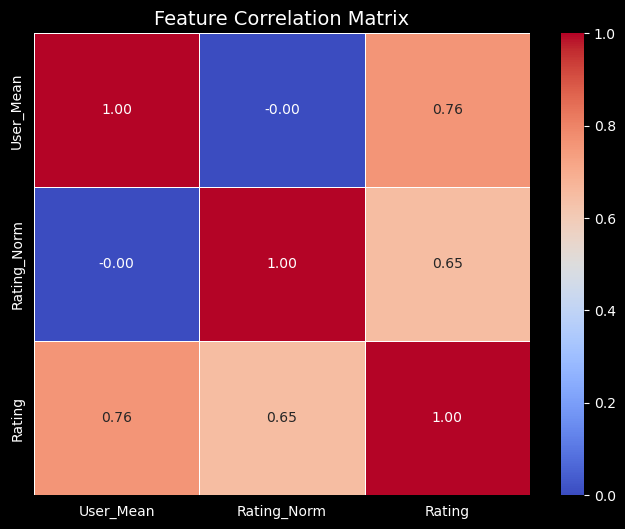

In [11]:
# Select only the numerical columns for correlation
corr_data = df[['User_Mean', 'Rating_Norm', 'Rating']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Feature Correlation Matrix', fontsize=14)
plt.savefig('plots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

#### Mean Predicted Norm: Top 10 Movies

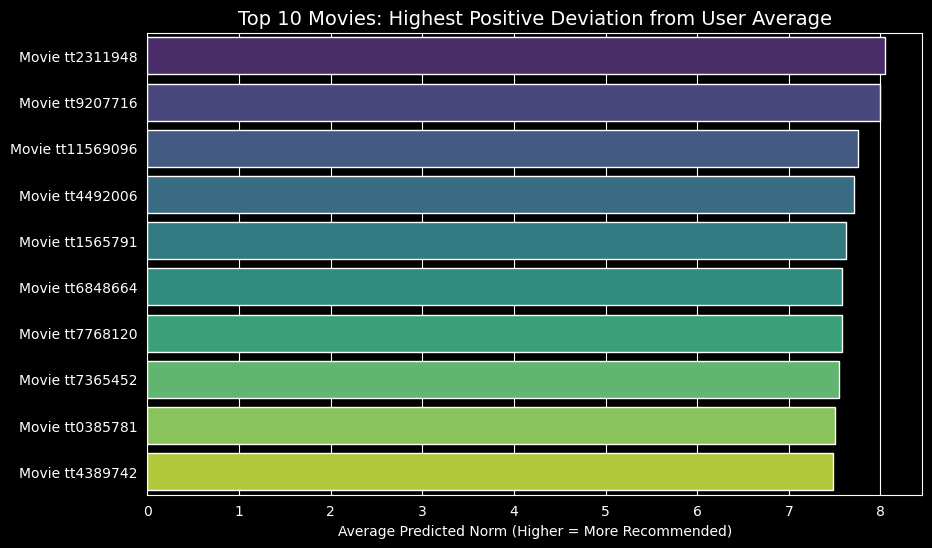

In [12]:
# Group by Movie_ID and find the average predicted norm
top_movies = df.groupby('Movie_ID')['Rating_Norm'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
# Fixed: Removed int(i) as IMDB IDs are strings
sns.barplot(
    x=top_movies.values,
    y=[f"Movie {i}" for i in top_movies.index],
    hue=top_movies.index,
    palette='viridis',
    legend=False
)

plt.title('Top 10 Movies: Highest Positive Deviation from User Average', fontsize=14)
plt.xlabel('Average Predicted Norm (Higher = More Recommended)')
plt.savefig('plots/top_10_recommendations.png', dpi=300, bbox_inches='tight')
plt.show()

#### TODO:: NA TO KSANADW GT TO KAINOURIO CSV THA EXEI POLLA LIGOTERA 3) Filter out user with 1 or 2 ratings. We dont need them and are noise

In [13]:
# Count ratings per user
user_counts = df.groupby('User_ID').size()

# Keep only users with 5 or more ratings
active_user_ids = user_counts[user_counts >= 5].index
df_filtered = df[df['User_ID'].isin(active_user_ids)].copy()

print(f"Original users: {len(user_counts):,}")
print(f"Active users (5+ ratings): {len(active_user_ids):,}")
print(f"Data remaining: {len(df_filtered):,} rows.")

Original users: 1,499,238
Active users (5+ ratings): 120,250
Data remaining: 2,822,422 rows.


### Now the code is able to predict the Rating_Norm. So the results mean either: 2.5 > **User will likely love current movie** or if < -3.0 **User will likely hate the movie**

### Build **User - Item Matrix**

In [14]:
# Initialize the encoders
user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

# Fit and transform the IDs into integer indices
df_filtered['user_idx'] = user_encoder.fit_transform(df_filtered['User_ID'])
df_filtered['movie_idx'] = movie_encoder.fit_transform(df_filtered['Movie_ID'])

# Let's see the result
n_users = df_filtered['user_idx'].nunique()
n_movies = df_filtered['movie_idx'].nunique()

print(f"✅ Label Encoding Complete.")
print(f"Total Unique Users: {n_users:,}")
print(f"Total Unique Movies: {n_movies:,}")
print(df_filtered[['User_ID', 'user_idx', 'Movie_ID', 'movie_idx']].head())

✅ Label Encoding Complete.
Total Unique Users: 120,250
Total Unique Movies: 296,050
     User_ID  user_idx   Movie_ID  movie_idx
1  ur3174947     63473  tt0118688      56791
2  ur3780035     70296  tt0387887     102045
4  ur3174947     63473  tt0094721      45010
5  ur1162550     23075  tt0114891      55016
8  ur3174947     63473  tt0120601      57899


#### Distribution & Threshold Analysis

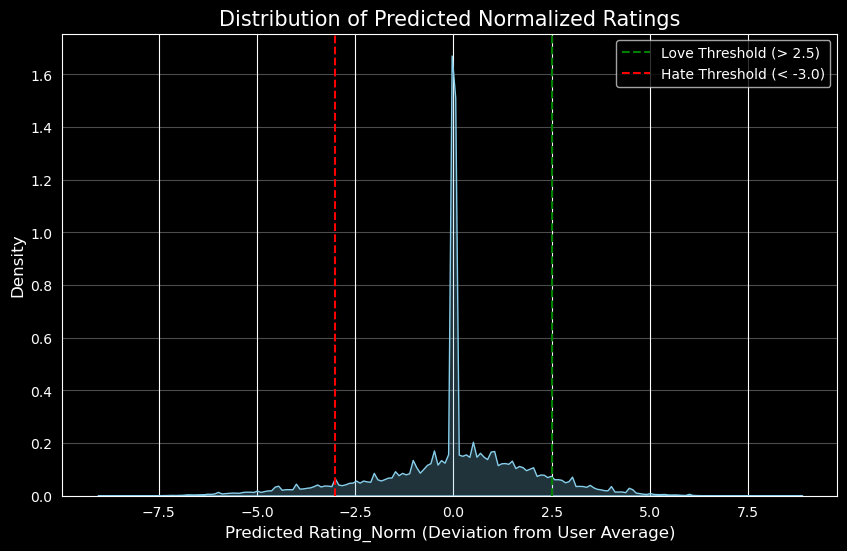

In [15]:
plt.figure(figsize=(10, 6))

# Plotting the density of predictions
sns.kdeplot(df['Rating_Norm'], fill=True, color="skyblue", bw_adjust=0.5)

# Adding the threshold lines
plt.axvline(2.5, color='green', linestyle='--', label='Love Threshold (> 2.5)')
plt.axvline(-3.0, color='red', linestyle='--', label='Hate Threshold (< -3.0)')

# Formatting
plt.title('Distribution of Predicted Normalized Ratings', fontsize=15)
plt.xlabel('Predicted Rating_Norm (Deviation from User Average)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.savefig('plots/distribution_&_threshold.png', dpi=300, bbox_inches='tight')

plt.show()

#### Spread of normalized rating. It will show if "Love" predictions are extreme outliers or not

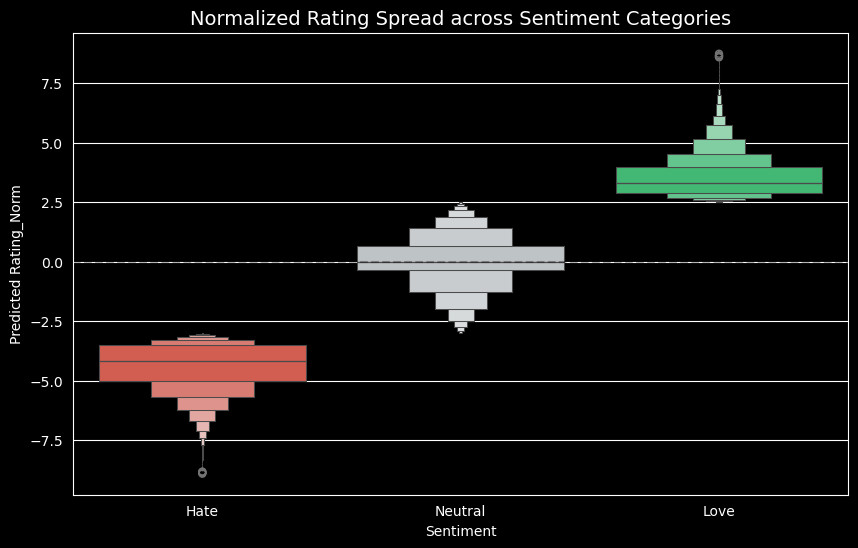

In [17]:
# 1. Create the Sentiment column first
def get_sentiment(x):
    if x > 2.5:
        return 'Love'
    elif x < -3.0:
        return 'Hate'
    else:
        return 'Neutral'

# Apply the function to create the missing column
df['Sentiment'] = df['Rating_Norm'].apply(get_sentiment)

# 2. Ensure the save directory exists
if not os.path.exists('plots'):
    os.makedirs('plots')

# 3. Now run your plotting code
plt.figure(figsize=(10, 6))

sns.boxenplot(
    data=df,
    x='Sentiment',
    y='Rating_Norm',
    hue='Sentiment',
    palette={'Love':'#2ecc71', 'Neutral':'#bdc3c7', 'Hate':'#e74c3c'},
    order=['Hate', 'Neutral', 'Love'],
    legend=False
)

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('Normalized Rating Spread across Sentiment Categories', fontsize=14)
plt.ylabel('Predicted Rating_Norm')
plt.savefig('plots/sentiment_boxen_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

#### Classification Count (The "Sentiment" Bar)

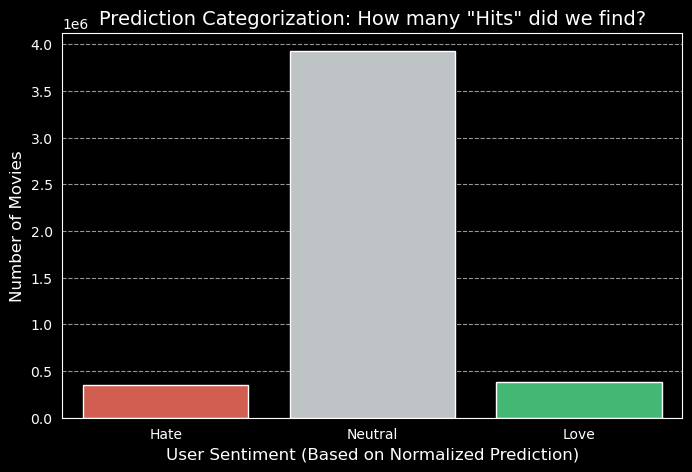

In [18]:
# Create a helper column for sentiment based on your thresholds
def get_sentiment(x):
    if x > 2.5: return 'Love'
    elif x < -3.0: return 'Hate'
    else: return 'Neutral'

# Applying the logic to your dataframe
df['Sentiment'] = df['Rating_Norm'].apply(get_sentiment)

# Plotting with the updated Seaborn syntax
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df,
    x='Sentiment',
    hue='Sentiment',
    palette={'Love':'#2ecc71', 'Neutral':'#bdc3c7', 'Hate':'#e74c3c'},
    order=['Hate', 'Neutral', 'Love'],
    legend=False              # Removes the redundant legend
)

plt.title('Prediction Categorization: How many "Hits" did we find?', fontsize=14)
plt.xlabel('User Sentiment (Based on Normalized Prediction)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.savefig('plots/rating_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

#### Because the data are too big, the **User - Item Matrix** will be compressed. This way K-means won't struggle

In [ ]:
# Create the matrix: (data, (row_indices, col_indices))
user_movie_sparse = csr_matrix(
    (df_filtered['Rating_Norm'], (df_filtered['user_idx'], df_filtered['movie_idx'])),
    shape=(n_users, n_movies)
)

print(f"✅ Sparse Matrix created with shape: {user_movie_sparse.shape}")